# Wellington H₂O: 30-, 60-, and 120-minute averaging

**60 minutes is a provisional compromise for spectral diagnostics and model fitting.**
It improves fit over half-hours with only a modest stationarity penalty. Two hours
adds more sensitivity to changing conditions. Keep half-hour processing available
for routine flux reporting and periods that do not support hourly averaging.
This does not establish a unique minimum-error averaging period.

The analysis covers **27 June–17 July 2024**, using matched observations rather
than different times. All timestamps follow the file convention without timezone
conversion. See [the detailed findings](wellington_averaging_findings.md) for
methods, exclusions, uncertainty checks, interpretation, and limitations.

Install the checkout with `pip install -e ".[notebooks]"`. The full local
`data/output/Wellington_filtered.parquet` dataset is required only for recomputation.
Saved cell outputs can be read without rerunning.

In [1]:
from pathlib import Path
import subprocess
import sys
import pandas as pd
from IPython.display import Image, display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "src/TaylorSwift/ec_spectral.py").is_file())
OUTPUT = ROOT / "examples/outputs/wellington_averaging_comparison"
UNTAPERED = ROOT / "examples/outputs/wellington_averaging_untapered"
RUN_ANALYSIS = False  # True reruns the complete record; allow several minutes.

if RUN_ANALYSIS:
    for flags in [[], ["--no-taper"]]:
        for script in ["compare_wellington_averaging.py", "summarize_wellington_averaging.py"]:
            subprocess.run([sys.executable, str(ROOT / "examples" / script), *flags],
                           cwd=ROOT, check=True)
if not (OUTPUT / "comparison_summary.csv").exists():
    raise FileNotFoundError("Set RUN_ANALYSIS=True to create the local comparison outputs.")
summary = pd.read_csv(OUTPUT / "comparison_summary.csv")
metrics = pd.read_csv(OUTPUT / "interval_metrics.csv", parse_dates=["parent", "start"])

## Matching and screening

Each two-hour window supplies four half-hours, two hours, and one two-hour record.
All four input channels must meet the same half-hour gap policy before any duration
is processed. At 10 Hz, coverage is typically 90%; only gaps ≤0.2 s are filled.
No additional despiking or WPL correction is performed.

244 of 252 windows pass coverage. Safe tapered spectral normalization in all seven
records leaves 191 matched windows. Requiring |wind–H₂O correlation| ≥0.1 in every
record leaves 143 stronger-signal windows. Results for both subsets are shown.
The 30% stationarity screen compares interval covariance with the mean of fixed
five-minute covariances. It is a necessary check, not comprehensive quality control.
Fits use a common 0.001111–1 Hz band to reduce confounding from changing fit limits.

,subset,minutes,intervals,parents,median_r2,steady_percent,median_trend_percent,median_slow3_percent,fit_boundary_percent,median_F
0,All matched,30,764,191,0.368,82.199,2.590,7.480,22.644,1.094
1,All matched,60,382,191,0.491,79.319,3.127,7.251,15.969,1.079
2,All matched,120,191,191,0.587,75.393,4.976,7.914,17.801,1.090
3,Stronger signal,30,572,143,0.365,93.007,1.682,5.566,16.783,1.087
4,Stronger signal,60,286,143,0.513,91.259,2.057,4.851,10.839,1.070
5,Stronger signal,120,143,143,0.619,88.811,2.611,5.059,11.189,1.074


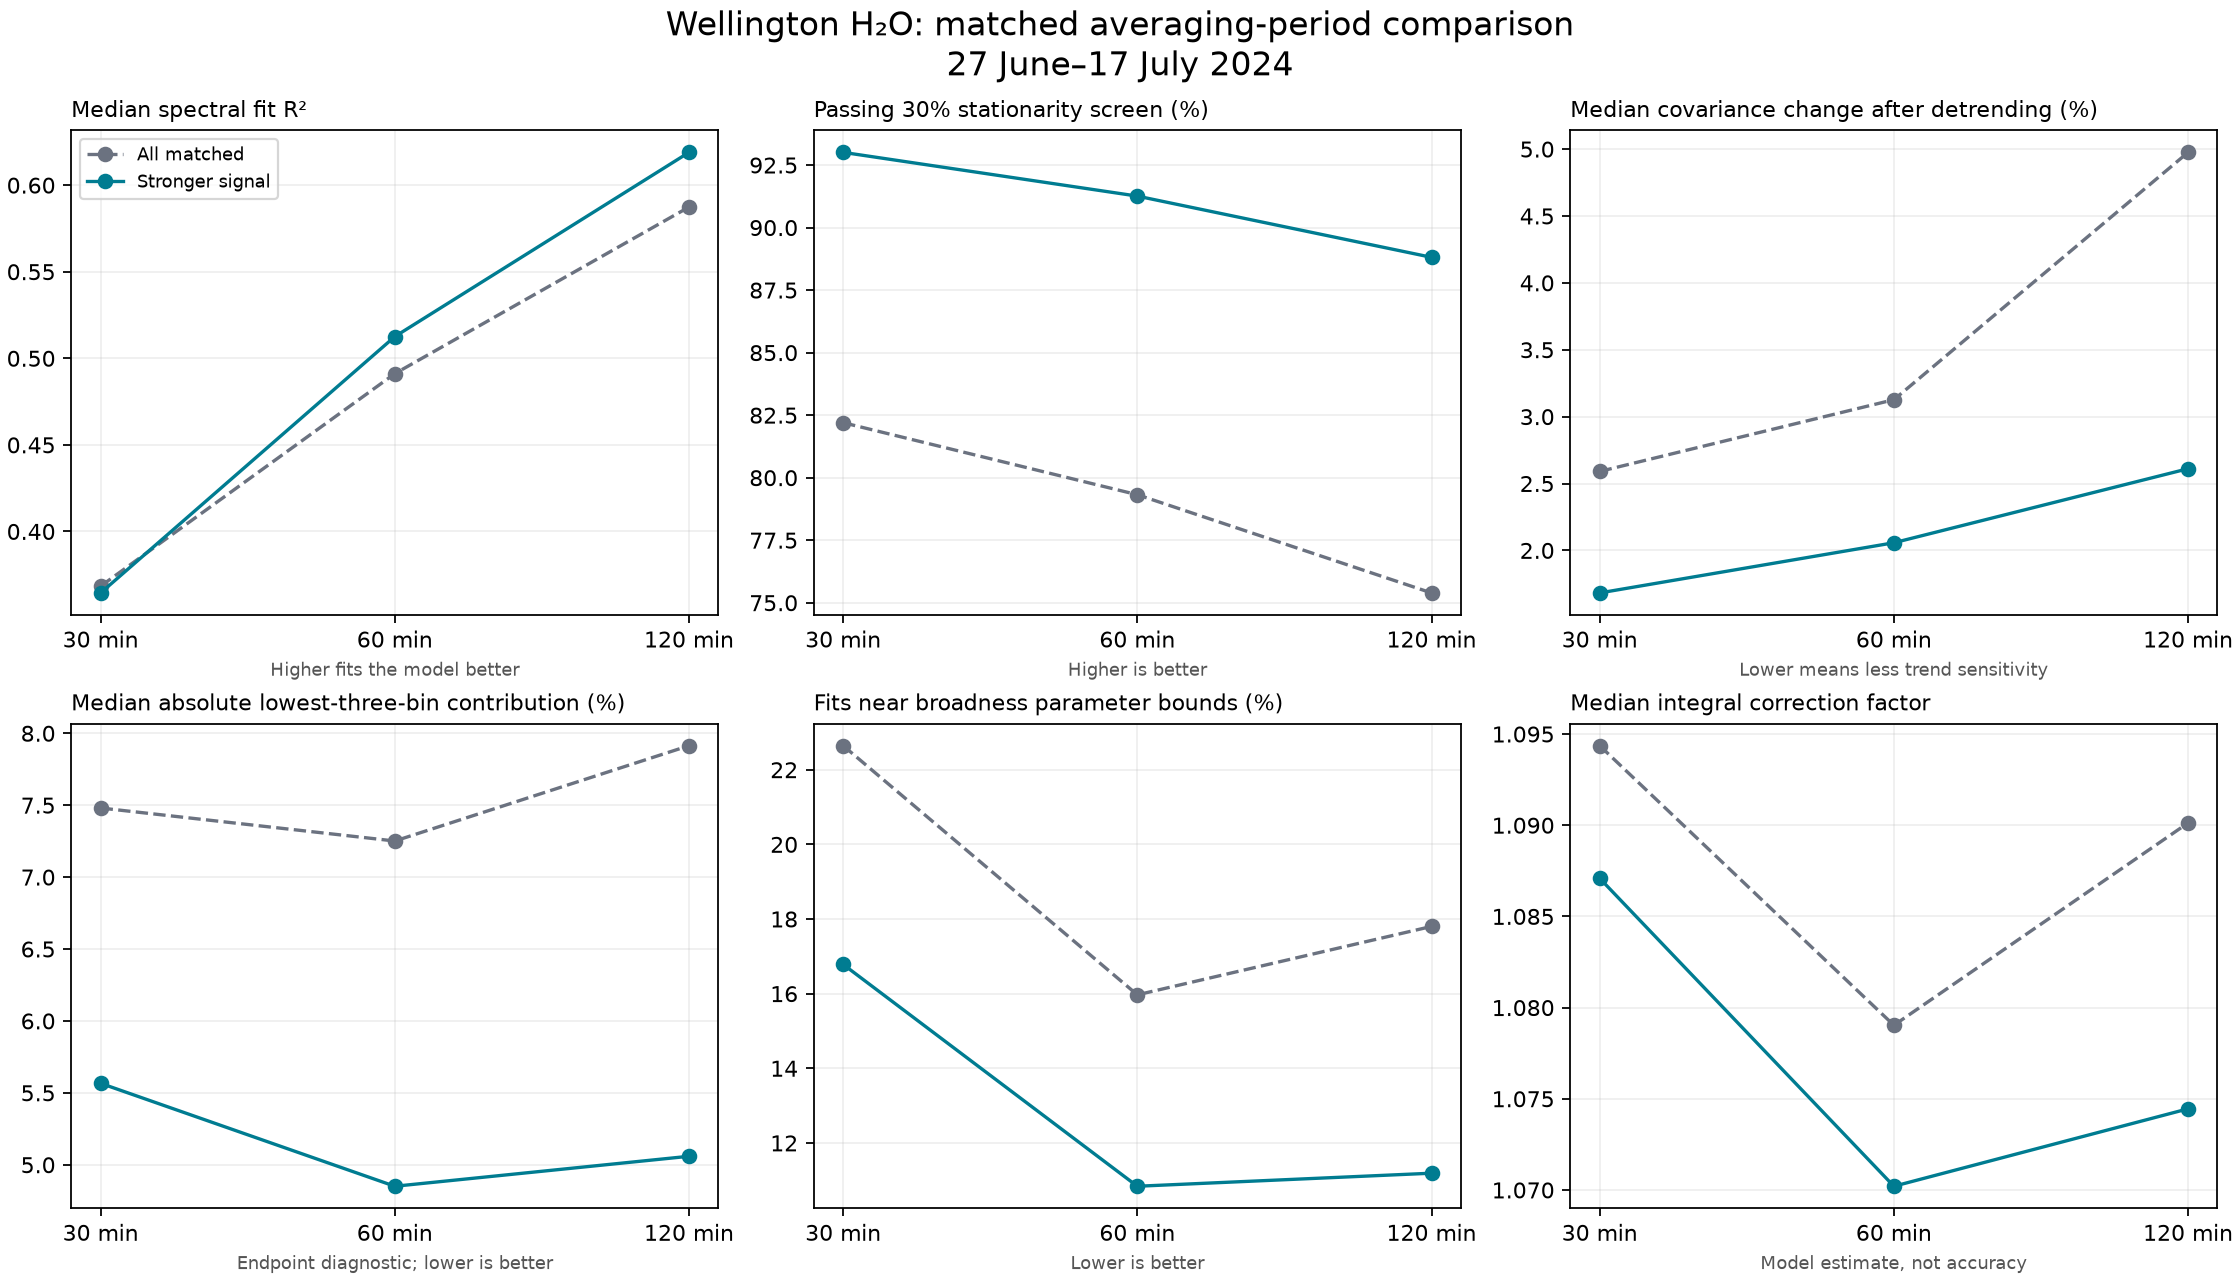

In [2]:
columns = ["subset", "minutes", "intervals", "parents", "median_r2", "steady_percent",
           "median_trend_percent", "median_slow3_percent", "fit_boundary_percent", "median_F"]
display(summary[columns].round(3))
display(Image(filename=str(OUTPUT / "averaging_comparison.png")))

## Interpret the comparison

In the stronger subset, median R² rises from **0.365 to 0.513 to 0.619**, while
stationarity pass rates decline from **93.0% to 91.3% to 88.8%**. Hourly averaging
has the smallest median lowest-three-bin contribution, but that improvement is
small and not statistically resolved by the paired daily analysis.

The lowest-three-bin measure uses absolute contributions divided by absolute net
covariance, at periods T, T/2, and T/3. It describes the relative low-frequency
endpoint, not a common frequency band or a validated missing-flux estimate.
An ogive endpoint at one is imposed by normalization. Longer records also smooth
binned spectra more, so increased R² is not proof of more accurate flux.

The fitted correction factors depend on assumed sensor response and geometry.
They are not used as a measure of accuracy.

## Compare exactly the screenshot's observations

These plots show all component intervals from **27 June, 14:00–16:00**. The
14:00 hour has weak fit; the 15:00 hour is better. The full two-hour interval has
66.8% stationarity deviation and 25.5% covariance sensitivity to linear detrending.
Its slowest three frequency bins have absolute contributions totaling 51.6% of
net covariance. This is a case where combining hours is unsuitable.

,,rho,common_r2,native_r2,stationarity,trend_sensitivity,slow3_abs
start,minutes,,,,,,
2024-06-27 14:00:00,30,0.2479,0.0100,0.0100,0.1011,0.2035,0.1296
2024-06-27 14:30:00,30,0.2182,0.2731,0.2731,0.0261,0.0929,0.3828
2024-06-27 15:00:00,30,0.2675,0.4254,0.4254,0.0123,0.0243,0.0485
2024-06-27 15:30:00,30,0.2019,0.2808,0.2808,0.1223,0.0812,0.1733
2024-06-27 14:00:00,60,0.1483,0.0397,0.0789,0.2208,0.2357,0.1378
2024-06-27 15:00:00,60,0.2006,0.5746,0.5579,0.0276,0.0735,0.1223
2024-06-27 14:00:00,120,0.4572,0.3306,-1.1659,0.6679,0.2549,0.5161


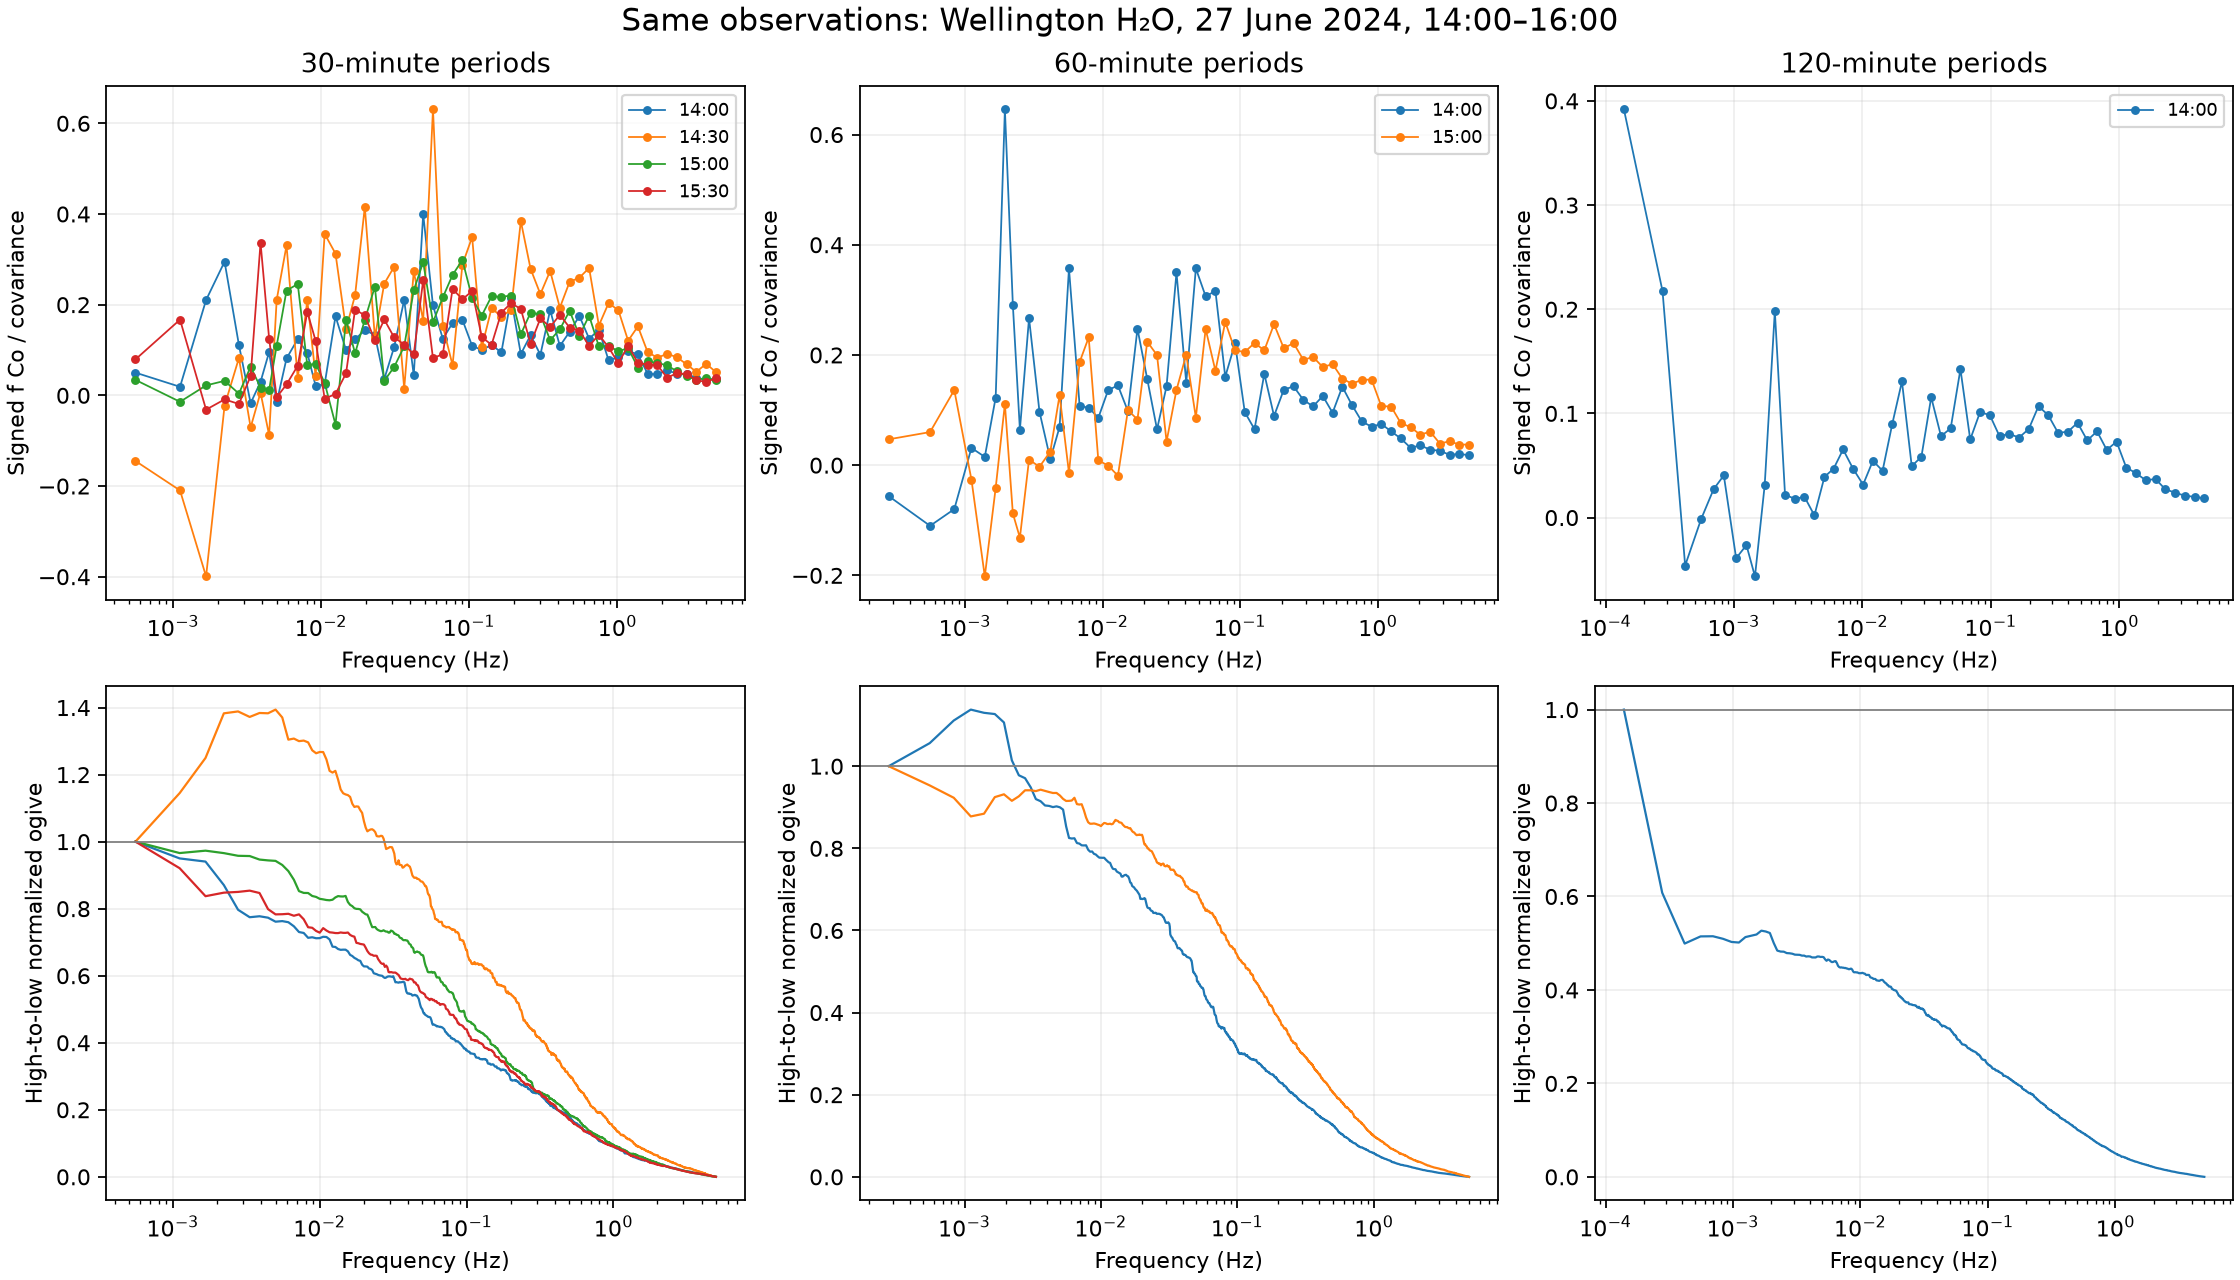

In [3]:
example = metrics[metrics.parent == pd.Timestamp("2024-06-27 14:00")]
display(example[["start", "minutes", "rho", "common_r2", "native_r2", "stationarity",
                 "trend_sensitivity", "slow3_abs"]].set_index(["start", "minutes"]).round(4))
display(Image(filename=str(OUTPUT / "matched_example.png")))

## Robustness and uncertainty

Without tapering all 244 eligible windows have usable spectra; 148 windows meet
the stronger-signal criterion. The overall fit–stationarity tradeoff persists.
This matters because the tapered method excluded 53 windows with one or more
incompatible spectra. Parameter-bound rates and individual fits do change.

The paired bootstrap first averages metrics within each matched two-hour window,
then computes daily differences and resamples the 21 days. Intervals sharing data
are not treated as independent. `steady30` differences are proportions, not percent;
for example −0.01 means a one-percentage-point reduction. The approximate intervals
reflect sampling across these days, not instrument or model uncertainty.

In [4]:
untapered_summary = pd.read_csv(UNTAPERED / "comparison_summary.csv")
display(untapered_summary[columns].round(3))
paired = pd.read_csv(OUTPUT / "paired_day_bootstrap.csv")
display(paired[paired.subset == "Stronger signal"].round(4))
sensitivity = pd.read_csv(OUTPUT / "threshold_sensitivity.csv")
display(sensitivity[sensitivity.subset == "Stronger signal"].pivot(
    index="threshold", columns="minutes", values="pass_percent").round(1))

,subset,minutes,intervals,parents,median_r2,steady_percent,median_trend_percent,median_slow3_percent,fit_boundary_percent,median_F
0,All matched,30,976,244,0.356,71.926,4.106,13.771,24.180,1.102
1,All matched,60,488,244,0.460,68.443,4.258,13.599,23.156,1.077
2,All matched,120,244,244,0.588,62.295,7.003,19.014,21.311,1.078
3,Stronger signal,30,592,148,0.400,91.047,1.757,7.188,12.838,1.085
4,Stronger signal,60,296,148,0.557,89.527,2.124,6.931,11.486,1.073
5,Stronger signal,120,148,148,0.671,86.486,2.990,7.442,5.405,1.069


,subset,minutes,metric,daily_mean_difference,ci_low,ci_high,days
8,Stronger signal,60,steady30,-0.0113,-0.0324,0.0092,21
9,Stronger signal,120,steady30,-0.0472,-0.0946,-0.0041,21
10,Stronger signal,60,common_r2,0.1147,0.0960,0.1327,21
11,Stronger signal,120,common_r2,0.2108,0.1690,0.2489,21
12,Stronger signal,60,trend_sensitivity,0.0075,-0.0092,0.0254,21
13,Stronger signal,120,trend_sensitivity,0.0287,0.0045,0.0558,21
14,Stronger signal,60,slow3_abs,-0.0131,-0.0294,0.0013,21
15,Stronger signal,120,slow3_abs,0.0131,-0.0275,0.0689,21


minutes,30,60,120
threshold,,,
0.1,74.0,70.3,64.3
0.2,89.0,85.3,80.4
0.3,93.0,91.3,88.8
0.5,95.3,95.5,92.3
1.0,99.1,99.0,99.3


## Use the result appropriately

Use **60 minutes for suitable H₂O spectral fitting intervals**, retain **30-minute
results when conditions change**, and avoid adopting **120 minutes as the default**.
This comparison alone does not justify replacing a standard half-hour flux product
with hourly fluxes. It also does not establish the optimum for CO₂ or heat.

No independent reference flux, energy-balance closure, footprint screening, or full
stationarity validation was performed. Approximately 10% gap interpolation affects
the high-frequency tail; instrument settings and prior filtering remain uncertain.
Do not interpret these covariances as WPL-corrected evaporation or latent heat flux.

Methodological context: [Vitale et al. (2020), stationarity and weak-flux limitations](https://bg.copernicus.org/articles/17/1367/2020/bg-17-1367-2020.html),
and [Karimindla et al. (2024), balancing averaging time and low-frequency capture](https://amt.copernicus.org/articles/17/5477/2024/index.html).
Detailed Wellington results and a full explanation are in [the findings report](wellington_averaging_findings.md).

Local output directories contain the per-interval CSV, coverage and failure records,
settings, figures, paired covariance comparison, and threshold/bootstrap summaries.
Rerunning replaces these generated files but never changes the source Parquet file.